## PFR(プラグフロー管型反応器）の設計方程式

<figure style="text-align:center;">
  <img
    src="https://raw.githubusercontent.com/myokota812/lecture/master/AdvChE/figure/pfr.svg"
    width="600">
</figure>


#### 　　　　　　　　　　　　PFRモデル

## 1. 設計方程式の導出

PFR反応器は一方向に反応液が流れ、管内で反応が生じる。左端の入口から任意の位置 $z$ に微小な体積要素 $dV$ をとる。この微小空間における物質収支を取ることから設計方程式が導出される。

**`定常状態`**における微小区間での物質収支は
$$
\mathrm{(流入量)}　-　\mathrm{(流出量)}　＋　\mathrm{(反応による増減量)} = 0
$$

$$
F\cdot C_A - F\cdot (C_A +dC_A )+ r_A dV =0
$$

これを整理すると

$$
\frac{dV}{F}=\frac{dC_A }{r_A }
$$

書き直すと

$$
\frac{dC_A }{dV}=\frac{r_A }{F} \tag{A}
$$  

または長さ方向 $z$ を変数にとると

$$
\frac{dC_A }{Sdz}=\frac{r_A }{F}\\
$$

$F=Su$ だから

$$
\frac{dC_A }{dz}=\frac{Sr_A }{F}=\frac{r_A }{u} 
$$ 

反応器容積 $V$ を求めるには、Eq. (A)について 反応器全体で積分する。


$$
\frac{V}{F}=\int_{C_{A0} }^{C_A } \frac{dC_A }{r_A }
$$

* $C_A$:成分Aの濃度 $\mathrm{mol}/\mathrm{m}^3$
* $S$ : 反応器断面積 $[\textrm{m}^2]$
* $F$ : 体積流量 $[\textrm{m}^3 \textrm{/s]}$
* $r_A$ :反応による生成速度 $[\textrm{mol/(m}^3 \cdot \textrm{s})]$
 （生成なら＋，消費なら$\textrm{-}$)
* $u$  :平均線流速 $[\textrm{m/s}]$
* $V$  :反応器体積　$[\textrm{m}^3]$ 



## 2. PFR解析（等温）


$$A\;\overset{k_1 }{\longrightarrow} \;D\;\overset{k_2 }{\longrightarrow} \;P$$

の場合

$$
\begin{aligned} 
\frac{dC_A }{dz}&=\frac{r_A }{u}\\
\frac{dC_D }{dz}&=\frac{r_D }{u}\\
\frac{dC_P }{dz}&=\frac{r_P }{u}
\end{aligned}
$$

$$
\begin{aligned} 
r_A &=-k_1 C_A\\
r_D &=k_1 C_A -k_2 C_D \\
r_P &=k_2 C_D . 
\end{aligned}
$$

これらの式を連立して解くと、PFRの任意位置（ $z$ )における各成分の分布を求めることができる。

下のコードを実行してください（コード各行の意味も理解してください）。


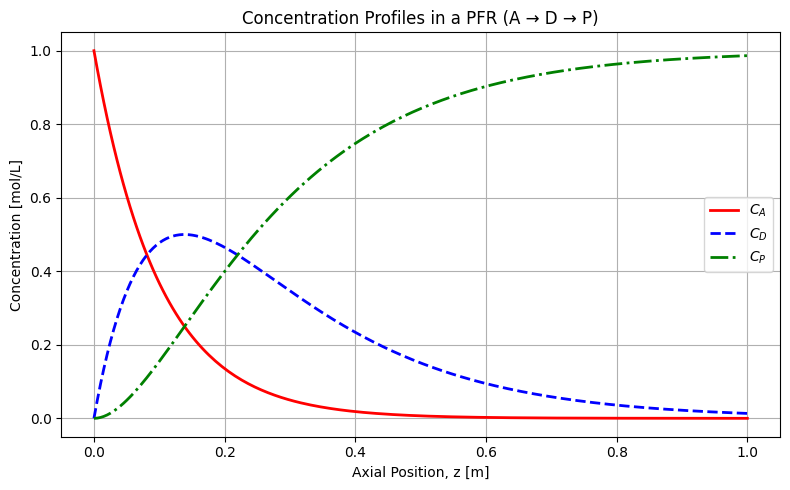

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
u = 0.1      # Superficial velocity [m/s]
k1 = 1.0     # A -> D rate constant
k2 = 0.5     # D -> P rate constant

CA0 = 1.0
CD0 = 0.0
CP0 = 0.0

# Initial conditions
C0 = [CA0, CD0, CP0]

# Reactor length
z_span = (0.0, 1.0)
z_eval = np.linspace(0, 1, 200)

# ODE system
def dCdz(z, C):
    CA, CD, CP = C

    dCA_dz = -k1 * CA / u
    dCD_dz = (k1 * CA - k2 * CD) / u
    dCP_dz = k2 * CD / u

    return [dCA_dz, dCD_dz, dCP_dz]

# Numerical solution
sol = solve_ivp(
    dCdz,
    z_span,
    C0,
    t_eval=z_eval,
    method="RK45"
)

# Results
z = sol.t
CA = sol.y[0]
CD = sol.y[1]
CP = sol.y[2]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(z, CA, 'r-',  lw=2, label=r'$C_A$')
plt.plot(z, CD, 'b--', lw=2, label=r'$C_D$')
plt.plot(z, CP, 'g-.', lw=2, label=r'$C_P$')

plt.xlabel('Axial Position, z [m]')
plt.ylabel('Concentration [mol/L]')
plt.title('Concentration Profiles in a PFR (A → D → P)')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

ほそく

。

理論解

この逐次反応
$$
A \rightarrow D \rightarrow P
$$
に対しては解析解も存在します。
$$
\begin{aligned}
C_A &=C_{A0}\exp\!\left(-\frac{k_1 z}{u}\right) \\ 
C_D &= \frac{k_1 C_{A0}} {k_2-k_1} \left[ \exp\!\left(-\frac{k_1 z}{u}\right) - \exp\!\left(-\frac{k_2 z}{u}\right) \right] \\ C_P &=C_{A0}-C_A-C_D
\end{aligned}
$$
なので、この例は数値解と解析解を比較する化学反応工学の演習問題としても使えます。

In [ ]:
#@title CODE1
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
u = 0.1      # Superficial velocity [m/s]
k1 = 1.0     # A -> D rate constant
k2 = 0.5     # D -> P rate constant

CA0 = 1.0
CD0 = 0.0
CP0 = 0.0

# Initial conditions
C0 = [CA0, CD0, CP0]

# Reactor length
x_span = (0.0, 1.0)
x_eval = np.linspace(0, 1, 200)

# ODE system
def dCdx(x, C):
    CA, CD, CP = C

    dCA_dx = -k1 * CA / u
    dCD_dx = (k1 * CA - k2 * CD) / u
    dCP_dx = k2 * CD / u

    return [dCA_dx, dCD_dx, dCP_dx]

# Numerical solution
sol = solve_ivp(
    dCdx,
    x_span,
    C0,
    t_eval=x_eval,
    method="RK45"
)

# Results
x = sol.t
CA = sol.y[0]
CD = sol.y[1]
CP = sol.y[2]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(x, CA, 'r-',  lw=2, label=r'$C_A$')
plt.plot(x, CD, 'b--', lw=2, label=r'$C_D$')
plt.plot(x, CP, 'g-.', lw=2, label=r'$C_P$')

plt.xlabel('Axial Position, x [m]')
plt.ylabel('Concentration [mol/L]')
plt.title('Concentration Profiles in a PFR (A → D → P)')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# <span style="color:rgb(213,80,0)">課題１</span>

code 1において、操作パラメーター( $u,k_1 ,k_2$ )の3つを色々と変化させて、グラフを見比べてください。

目的成分を中間体Dとし、Dの出口濃度に注目するとどのパラメーターが一番感度が高いか、シミュレーションを通して、結論づけ、 ***解答欄1*** に記入してください。単に「ｋ１」とだけ答えるのではなくて、シミュレーション結果もしくは基礎式をベースに、そう考えた根拠も示してください。

========== (参考）========

CDの計算結果は、コマンドウィンドウで

<pre>
>> CD
</pre>

と入力すれば、見ることができます。ワークスペースのCDを見ると分かるのですが、77x1のベクトル量として保存されております。課題のためにはCDの最後の値が必要ですが、

<pre>
>> CD(end)
</pre>

でそれを見ることができます。

===（解答欄1）==========

（必要なら下表を使ってください。）

|||||
| :-- | :-- | :-- | :-- |
| $\displaystyle u$ <br>  | $\displaystyle k_1$ <br>  | $\displaystyle k_2$ <br>  | $C_D$ (end) <br>   |
| 0.1 <br>  | 1.0 <br>  | 0.5 <br>  | 0.0134 <br>   |
|  |  |  |   |
|  |  |  |   |
|  |  |  |   |

行を追加：表の最終行の任意の位置をクリックした状態で、

右クリック/テーブル/\[下に行を追加」

====  **解答記述欄** ========

======================

解答後次に進んでください。

パラメーターの感度解析の一例を以下に示します。

実行してみてください。


In [ ]:
#@title感度解析
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd

# ==================================================
# Sensitivity Analysis: A -> D -> P
# Desired product = D
# ==================================================

# ----------------------------
# Base parameters
# ----------------------------
u = 0.1      # Velocity [m/s]
k1 = 1.0     # A -> D rate constant
k2 = 0.5     # D -> P rate constant

CA0 = 1.0
CD0 = 0.0
CP0 = 0.0

L = 1.0      # Reactor length [m]

C0 = [CA0, CD0, CP0]

# ----------------------------
# PFR model
# ----------------------------
def reactor_model(x, C, u, k1, k2):

    CA, CD, CP = C

    dCA_dx = -k1 * CA / u
    dCD_dx = (k1 * CA - k2 * CD) / u
    dCP_dx = k2 * CD / u

    return [dCA_dx, dCD_dx, dCP_dx]

# ----------------------------
# Base simulation
# ----------------------------
sol = solve_ivp(
    reactor_model,
    [0, L],
    C0,
    args=(u, k1, k2),
    rtol=1e-10,
    atol=1e-12
)

CA_out = sol.y[0, -1]
CD_out = sol.y[1, -1]
CP_out = sol.y[2, -1]

print("=== Base Case ===")
print(f"CA(L) = {CA_out:.6e}")
print(f"CD(L) = {CD_out:.6e}")
print(f"CP(L) = {CP_out:.6e}")

# ==================================================
# Exact analytical sensitivities
# ==================================================

EA = np.exp(-k1 * L / u)
ED = np.exp(-k2 * L / u)

CD_exact = (
    k1 * CA0 / (k2 - k1)
) * (EA - ED)

# ----------------------------
# dCD/dk1
# ----------------------------
dCD_dk1 = CA0 * (
    (EA - ED) / (k2 - k1)
    + (k1 / (k2 - k1)) * (-L / u) * EA
    - (k1 / (k2 - k1)**2) * (EA - ED)
)

# ----------------------------
# dCD/dk2
# ----------------------------
dCD_dk2 = CA0 * (
    -(k1 / (k2 - k1)**2) * (EA - ED)
    + (k1 / (k2 - k1)) * (L / u) * ED
)

# ----------------------------
# dCD/du
# ----------------------------
dCD_du = (
    k1 * CA0 / (k2 - k1)
) * (
    (k1 * L / u**2) * EA
    - (k2 * L / u**2) * ED
)

# ----------------------------
# Normalized sensitivities
# S = (p/CD) * dCD/dp
# ----------------------------
S_k1 = (k1 / CD_exact) * dCD_dk1
S_k2 = (k2 / CD_exact) * dCD_dk2
S_u  = (u  / CD_exact) * dCD_du

# ==================================================
# Sensitivity table
# ==================================================

results = pd.DataFrame({
    "Parameter": ["k1", "k2", "u"],
    "Sensitivity": [S_k1, S_k2, S_u]
})

print("\n=== Exact Sensitivities ===")
print(results.to_string(index=False))

# ==================================================
# Bar chart
# ==================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    results["Parameter"],
    results["Sensitivity"]
)

plt.axhline(0, color='black', linewidth=1)

plt.xlabel("Parameter")
plt.ylabel("Normalized Sensitivity")
plt.title("Sensitivity of Outlet D Concentration")

plt.tight_layout()
plt.show()


実行結果の解釈

 *`例えば`* 結果が以下であったとします。

| **Parameter** <br>  | **Sensitivity** <br>   |
| :-- | :-- |
| k1 <br>  | +0.75 <br>   |
| k2 <br>  | −0.82 <br>   |
| u <br>  | −0.93 <br>   |

Snsitivityの数値が

- **正の値（+）** → 増やすと $C_D$ が増える
- **負の値（−）** → 増やすと $C_D$ が減る
- **絶対値が大きいほどセンシティブ**

**感度解析の結果は**課題１の予想と比べていかがでしたか？

# <span style="color:rgb(213,80,0)">課題２</span>

上の感度解析コードはなにを計算していますか。コードから読み取ってください。

数式（Latex不使用）を記述する場合、

dcA/dt =k1 cA

などの記述で結構です。

====（解答欄）===========

========================

## 3. PFRとCSTRの比較

第１１回の講義で非等温CSTRの解析を実施しましたが、それと同じ反応系

$$\begin{array}{l} A\;\overset{k_1 }{\to} \;D\;\overset{k_2 }{\to} \;U\newline A+A\;\overset{k_3 }{\to} \;P \end{array}$$

（ただし断熱）、についてCSTRとPFRの比較を行うコードを以下に示します。

一通りコードを解読し、実行してください。実行後、課題に取り組んでください。


In [ ]:
#@title CSTR vs PFR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================
# CSTR vs PFR Comparison
# Adiabatic Reactor
# A -> D -> U
# 2A -> P
# =====================================================

# -----------------------------
# Kinetic parameters
# -----------------------------

k0 = np.array([
    1.777e8,
    5.326e6,
    6.223e4
])

E = np.array([
    7.878e4,
    7.479e4,
    6.842e4
])

R = 8.3145

# -----------------------------
# Heat of reaction [J/mol]
# -----------------------------

H = np.array([
    -4.2e4,
    -11.0e4,
    -41.85e4
])

# -----------------------------
# Feed conditions
# -----------------------------

CA0 = 100.0
CD0 = 0.0
CU0 = 0.0
CP0 = 0.0

Tin = 380.0
T0 = 300.0

rho = 1000.0
Cp = 4.18e3

tau_list = np.array([
    500,
    1000,
    3000,
    6000,
    10000
])

# =====================================================
# Arrhenius Law
# =====================================================

def kfun(T):

    k1 = k0[0] * np.exp(-E[0] / (R*T))
    k2 = k0[1] * np.exp(-E[1] / (R*T))
    k3 = k0[2] * np.exp(-E[2] / (R*T))

    return k1, k2, k3

# =*==================================*================
# CSTR Model
# ==*==================================*===============
def cstr_rhs(t, X, tau):

    CA, CD, CU, CP, T = X
    k1, k2, k3 = kfun(T)

    r1 = k1 * CA
    r2 = k2 * CD
    r3 = k3 * CA**2

    qdot = -(H[0]*r1 + H[1]*r2 + H[2]*r3)

    dCA = (CA0 - CA)/tau - r1 - 2*r3
    dCD = (CD0 - CD)/tau + r1 - r2
    dCU = (CU0 - CU)/tau + r2
    dCP = (CP0 - CP)/tau + r3

    dT = (Tin - T)/tau + qdot/(rho*Cp)

    return [dCA, dCD, dCU, dCP, dT]

# =====================================================
# PFR Model
# =====================================================

def pfr_rhs(theta, Y):

    CA, CD, CU, CP, T = Y

    k1, k2, k3 = kfun(T)

    r1 = k1 * CA
    r2 = k2 * CD
    r3 = k3 * CA**2

    qdot = -(H[0]*r1 + H[1]*r2 + H[2]*r3)

    dCA = -r1 - 2*r3
    dCD = r1 - r2
    dCU = r2
    dCP = r3

    dT = qdot/(rho*Cp)

    return [dCA, dCD, dCU, dCP, dT]

# =====================================================
# Simulation
# =====================================================

nTau = len(tau_list)

res_CSTR = np.zeros((nTau, 5))
res_PFR = np.zeros((nTau, 5))

for i, tau in enumerate(tau_list):

    # ----------------------
    # CSTR
    # ----------------------

    X0 = [CA0, 0, 0, 0, T0]

    sol_cstr = solve_ivp(
        cstr_rhs,
        [0, 10*tau],
        X0,
        args=(tau,),
        method='BDF',
        rtol=1e-8,
        atol=1e-10
    )

    res_CSTR[i, :] = sol_cstr.y[:, -1]

    # ----------------------
    # PFR
    # ----------------------

    Y0 = [CA0, 0, 0, 0, Tin]

    sol_pfr = solve_ivp(
        pfr_rhs,
        [0, tau],
        Y0,
        method='BDF',
        rtol=1e-8,
        atol=1e-10
    )

    res_PFR[i, :] = sol_pfr.y[:, -1]

# =====================================================
# Results Table
# =====================================================

columns = ['CA', 'CD', 'CU', 'CP', 'T']

print("\n===== CSTR Steady State =====")
print(pd.DataFrame(
    res_CSTR,
    index=tau_list,
    columns=columns
))

print("\n===== PFR Outlet =====")
print(pd.DataFrame(
    res_PFR,
    index=tau_list,
    columns=columns
))

# =====================================================
# Plot Settings
# =====================================================

lw = 2
ms = 7

# -----------------------------------------------------
# CA
# -----------------------------------------------------

plt.figure(figsize=(6,4))

plt.plot(tau_list,res_CSTR[:,0],'ro-',lw=lw,ms=ms,label='CSTR')
plt.plot(tau_list,res_PFR[:,0],'rx--',lw=lw,ms=ms,label='PFR')

plt.xlabel('Residence Time τ [s]')
plt.ylabel('CA [mol/m³]')
plt.title('A Component')
plt.grid()
plt.show()


# <span style="color:rgb(213,80,0)">課題３</span>

PFRとCSTRは全く異なる装置です。上のコードでは、両者を比較するために、何を基準にしているのか解答してください。（簡潔で結構です。）

====（解答欄）===========

========================

# <span style="color:rgb(213,80,0)">課題４</span>

上記のコードを実行後、出力された結果（表およびグラフ）を受けて、CSTRとPFRの比較を行ってください。

単に、出力値を比較下だけの定性的な記述は、評価は50％程度とします。表に数値がありますので、定量的に論じてください。コードには記載されていない指標を提案され、定量的に論じられることを期待します。

====（解答欄）===========

========================

以上です。

### 解説

CSTR（完全混合槽反応器）
PFR（押出流反応器）

について、

$$
\mathrm{A} \rightarrow \mathrm{D} \rightarrow \mathrm{U}
$$

と

$$
\mathrm{A} \rightarrow \mathrm{P}
$$

が同時に起こる **断熱反応器（Adiabatic Reactor）** をモデル化し、滞留時間 $\tau$ を変えたときの出口組成と温度を比較しています。

### 1. 反応速度の計算

まず Arrhenius 式から速度定数を計算しています。

$$
\begin{aligned}
k_1 &= k_0 [0] * np.exp(-E[0] / (R*T))\\
k_2 &= k0[1] * np.exp(-E[1] / (R*T))\\
k_3 &= k0[2] * np.exp(-E[2] / (R*T))\\
\end{aligned}
$$

つまり

$$
k_i = k_{0,i} \exp\left( -\frac{E_i}{RT} \right)
$$
です。

温度 $T$ が高いほど反応が速くなります。

### 2. 反応速度

* 反応1: 
 $
 A \rightarrow D\\
r_1 = k_1 C_A
 $

* 反応2 : 
$
D \rightarrow U\\
r_2 = k_2 C_D
$

* 反応3 : 
$
2A \rightarrow P\\
r_3 = k_3 C_A^2
$


### 3. 発熱量の計算

各反応の反応熱を足し合わせます。
$$
\dot q = -\left( \Delta H_1 r_1 + \Delta H_2 r_2 + \Delta H_3 r_3 \right)
$$
反応熱が負なので発熱反応です。

例えば

$\Delta H=-42000\ {\rm J/mol}$

なら
$-\Delta H r > 0$

となり温度上昇を引き起こします。

### 4. CSTRでは何を計算しているか

CSTR の物質収支

$$
\frac{dC_A}{dt} = \frac{C_{A0}-C_A}{\tau} -r_1 -2r_3
$$

右辺第１項は$\text{流入} - \text{流出}$です。

右辺の第２，３項が反応による生成と消費です。

Aは

$A \rightarrow D$で 1 mol 消費

$2A \rightarrow P$で 2 mol 消費されます。

したがって
$-r_1 -2r_3$
になります。

同様にDは
$$
\frac{dC_D}{dt} = \frac{C_{D0}-C_D}{\tau} + r_1 - r_2
$$
です。

◇◇◇

温度収支は

$$
\frac{dT}{dt} = \frac{T_{in}-T}{\tau} + \frac{\dot q}{\rho C_p}
$$
となります。

5. なぜ solve_ivp を使うか
sol_cstr = solve_ivp(...)


は

dXdt=f(X)\frac{dX}{dt}=f(X)

を数値積分しています。

初期値

X0=[100,0,0,0,300]


から開始して、

0 ～ 10*tau


まで積分します。

十分長時間積分すると

dXdt=0\frac{dX}{dt}=0

に近づきます。

つまり定常状態を求めています。

6. PFRでは何を計算しているか

PFRでは時間ではなく

theta


を反応器内の滞留時間座標として使っています。

式は

dCA = -r1 -2*r3


のみです。

CSTRにあった

(CA0-CA)/tau


がありません。

なぜならPFRは微小要素ごとの定常物質収支だからです。

$$
\frac{dC_A}{d\theta} = -r_1 - 2r_3
$$
です。

温度も

dT = qdot/(rho*Cp)


なので

dTdθ=q˙ρCp\frac{dT}{d\theta} = \frac{\dot q}{\rho C_p}

です。

7. 求められるもの

最終的に

res_CSTR


には

τ=500, 1000, 3000, 6000, 10000\tau = 500,\, 1000,\, 3000,\, 6000,\, 10000

秒ごとの

(CA,CD,CU,CP,T)(C_A,C_D,C_U,C_P,T)

の定常値が入ります。

例えば

res_CSTR[i,:]


は

[CA,CD,CU,CP,T][C_A,C_D,C_U,C_P,T]

です。

8. このモデルで期待される傾向

一般に同じ滞留時間なら

PFRの方が転化率が高い
A濃度はPFRの方が低い
発熱反応ならPFRの方が温度上昇しやすい

ので

CA,PFR<CA,CSTRC_{A,\mathrm{PFR}} < C_{A,\mathrm{CSTR}}

になることが多いです。

ただしこの系は

A→D→UA \rightarrow D \rightarrow U

という逐次反応を含むため、

中間生成物 D の収率は必ずしも PFR が有利とは限りません。

なお、このコードにはまだ

plt.show()


がなく、後半が切れているようなので、グラフ描画部分の完成版を見るとさらに「何を比較しているか」が分かります。